In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import pandas as pd

df = pd.read_csv('AmesHousing.csv')

print(df.head())
print(df.columns)

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving AmesHousing.csv to AmesHousing (1).csv


In [ ]:
target_column = 'SalePrice'


X = df.drop(target_column, axis=1)

y = df[target_column]


In [ ]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


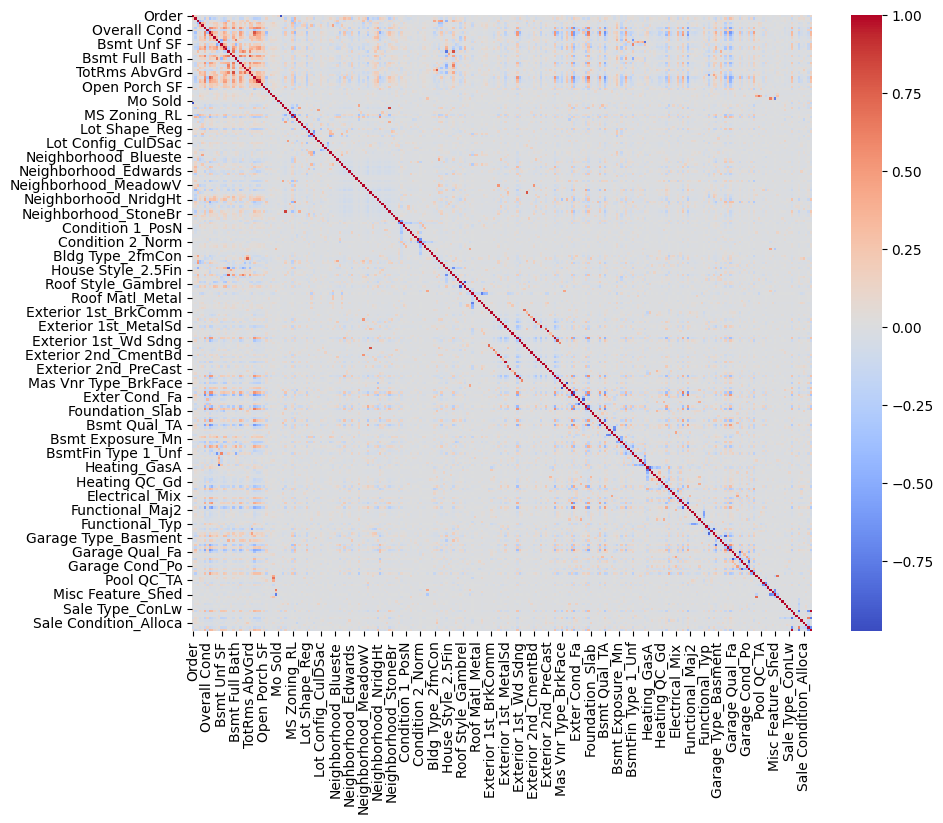

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Random Forest Score: {rf_model.score(X_test, y_test):.2f}")


In [ ]:
import pandas as pd
import numpy as np

data = {
    'Size_sqft': [1500, 2000, 2500, 1800, 2100, 3000, 2200, 4800, 1200, 5000],
    'Bedrooms': [3, 4, 3, 2, 3, 5, 3, 6, 2, 7],
    'Age': [10, 5, 15, 20, 12, 2, 8, 1, 30, 0],
    'Pool': [0, 1, 0, 0, 0, 1, 0, 1, 0, 1],
    'Price': [300000, 450000, 380000, 310000, 390000, 600000, 410000, 950000, 250000, 1100000]
}
df = pd.DataFrame(data)

correlation = df.corr()
print("Correlation with Price:\n", correlation['Price'].sort_values(ascending=False))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.select_dtypes('number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with House Price')
plt.show()



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)


print(f"R-squared (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):,.2f}")


R-squared (Accuracy): 0.9124
Mean Squared Error: 702,375,745.05


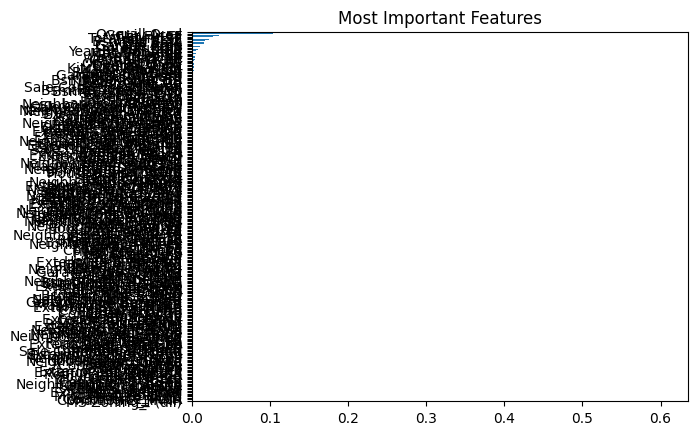

In [ ]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Most Important Features')
plt.show()


In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [22]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("XGBoost Training Complete!")

# Evaluate
print(f"XGBoost R2 Score: {xgb_model.score(X_test, y_test):.4f}")


XGBoost Training Complete!
XGBoost R2 Score: 0.9254


In [23]:
X_for_corr = X.copy()
X_for_corr['SalePrice'] = y
correlations = X_for_corr.corr()['SalePrice'].sort_values(ascending=False)

top_features = correlations.index[1:6]
print(f"Training only on: {list(top_features)}")

X_selected = X[top_features]

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

scaler_small = StandardScaler()
X_train_small_scaled = scaler_small.fit_transform(X_train_selected)
X_test_small_scaled = scaler_small.transform(X_test_selected)

xgb_model.fit(X_train_small_scaled, y_train_selected)

print("XGBoost Training Complete on Top 5 Features!")
print(f"XGBoost R2 Score (Top 5 Features): {xgb_model.score(X_test_small_scaled, y_test_selected):.4f}")

Training only on: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF']
XGBoost Training Complete on Top 5 Features!
XGBoost R2 Score (Top 5 Features): 0.8872


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = xgb_model.predict(X_test_small_scaled)

r2 = r2_score(y_test_selected, y_pred)
mae = mean_absolute_error(y_test_selected, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_selected, y_pred))

print(f"✅ Final R2 Score: {r2:.4f}")
print(f"✅ Average Error (MAE): ${mae:,.2f}")
print(f"✅ Root Mean Squared Error (RMSE): ${rmse:,.2f}")

✅ Final R2 Score: 0.8872
✅ Average Error (MAE): $20,016.62
✅ Root Mean Squared Error (RMSE): $30,077.29


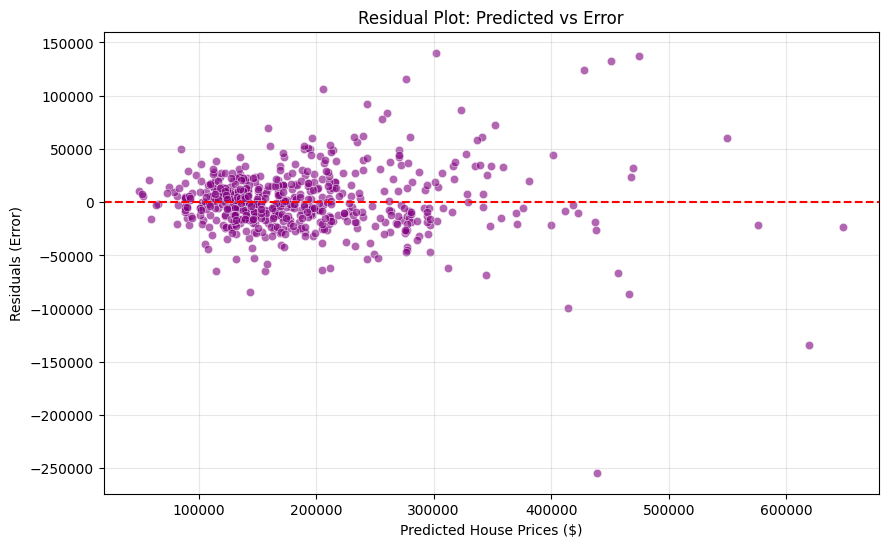

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot: Predicted vs Error')
plt.xlabel('Predicted House Prices ($)')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)
plt.show()


In [26]:

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df.to_csv('house_price_results.csv', index=False)


In [27]:
fast_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    max_samples=0.5,
    n_jobs=-1,
    random_state=42
)

fast_model.fit(X_train, y_train)
print("Finished! No more waiting.")


Finished! No more waiting.


In [28]:
ames_housing_corr_df = X.copy()
ames_housing_corr_df['SalePrice'] = y
correlations_ames = ames_housing_corr_df.corr()['SalePrice'].abs().sort_values(ascending=False)
top_10_ames = correlations_ames.index[1:11]
print(f"Training fast model only on: {list(top_10_ames)}")

X_ames_selected_fast = X[top_10_ames]

X_train_fast_selected, X_test_fast_selected, y_train_fast, y_test_fast = train_test_split(
    X_ames_selected_fast, y, test_size=0.2, random_state=42
)

scaler_fast = StandardScaler()
X_train_fast_scaled = scaler_fast.fit_transform(X_train_fast_selected)
X_test_fast_scaled = scaler_fast.transform(X_test_fast_selected)

fast_model.fit(X_train_fast_scaled, y_train_fast)

print("Fast model training complete on Top 10 Ames Housing Features!")



Training fast model only on: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Exter Qual_TA', 'Year Built', 'Full Bath', 'Year Remod/Add']
Fast model training complete on Top 10 Ames Housing Features!


In [29]:
from sklearn.linear_model import Ridge


ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
print(f"Accuracy: {ridge_model.score(X_test, y_test):.2f}")


Accuracy: 0.84


In [39]:

y_train_log = np.log1p(y_train)

best_model.fit(X_train, y_train_log)


y_pred_log = best_model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)


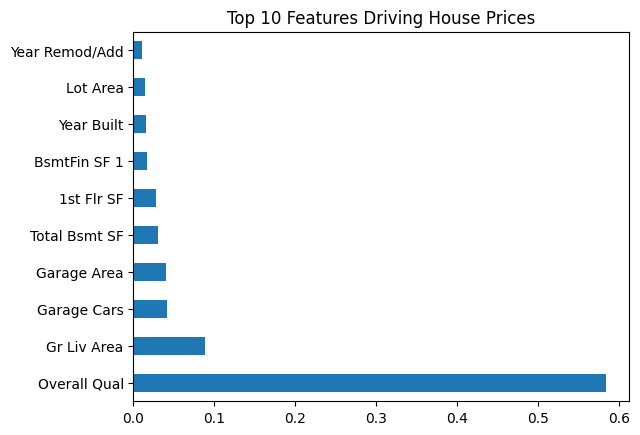

In [40]:

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features Driving House Prices')
plt.show()
